**Description**: sanity check that training isn't bottlenecked by dataloading. We're not. GPU util is 90-100%. All
dataloading takes ~6 min on my machine.

**Expected time**: 6.5 min.

In [ ]:
import math
import time
import warnings

from datetime import datetime
import numpy as np
import seaborn as sns
from sentence_transformers import SentenceTransformerTrainingArguments
from sentence_transformers.training_args import MultiDatasetBatchSamplers
import torch
from tqdm.auto import tqdm

import grouping_trainer as gt

In [2]:
sns.set_theme(style="darkgrid")

In [3]:
timestamp = datetime.now().strftime("%Y-%m-%d-%H-%M-%S")

RUN_SHORTNAME = "gte-no-synthetic-semi-easy-negatives"

SAMPLE_TRAIN: int | None = None
SAMPLE_VAL: int | None = 8000

PER_DEVICE_TRAIN_BATCH_SIZE = 256
GRADIENT_ACCUMULATION_STEPS = 1
GRADIENT_CHECKPOINTING = not torch.cuda.is_available()  # turn off if model supports flash attn

PER_DEVICE_EVAL_BATCH_SIZE = 2
EVAL_STEPS = 300
PER_DEVICE_TOKEN_BUDGET = 8192 * 4  # increased for A100 80GB

OUTPUT_DIR = f"./{timestamp}-{RUN_SHORTNAME}-output"

assert (EVAL_STEPS % 5) == 0, "pls for sanity make it divisible by 5"

gt.utils._cuda_empty_cache()

# model_path = "issue_grouping_v1/embeddings"
# # model_path = "/Users/kdubey/projects/seer/models/issue_grouping_v1/embeddings"
# model = gt.utils.SentenceTransformer(
#     str(model_path),
#     trust_remote_code=True,
#     # model_kwargs=dict(
#     #     dtype=torch.bfloat16,
#     #     attn_implementation="sdpa",  # not possible for jina-ai :-(
#     # )
# )
# model.device

model = gt.utils.SentenceTransformer(
    "Alibaba-NLP/gte-modernbert-base",
    # model_kwargs=dict(
    #     dtype=torch.bfloat16,
    #     attn_implementation="sdpa",
    # ),
)

assert "layernorm" in repr(model[0].auto_model).lower()
assert "batch" not in repr(model[0].auto_model).lower()

# Don't have batch norm. That could mess up stuff for the deduplication strategy.

In [4]:
_ = model.encode("test")

In [ ]:
dataset_val = gt.train.df_to_dataset(gt.data.load_val_df(sample_size=SAMPLE_VAL))
len(dataset_val)

In [ ]:
dataset_dict_train, frac_positive = gt.data.load_train_dataset_dict(
    sample_size=SAMPLE_TRAIN,
    min_dataset_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    # paths=("final_csvs/train-no-sentry.csv", "final_csvs/synthetic-semi-easy-negatives.csv"),
)
len(dataset_dict_train)

In [7]:
sum(dataset_dict_train.num_rows.values())

835765

In [8]:
evaluator = gt.evaluator.MinPrecisionEvaluator(
    sentences1=list(dataset_val["query_stacktrace_string"]),
    sentences2=list(dataset_val["candidate_stacktrace_string"]),
    labels=[int(record["label"]) for record in dataset_val],
    name="val",
    show_progress_bar=True,
    batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    truncate_dims=(64, 768),
)

In [9]:
def init_bias(frac_positive: float):
    return math.log(frac_positive / (1 - frac_positive))


trainer = gt.train.Trainer(
    model=model,
    args=SentenceTransformerTrainingArguments(
        # These should prolly be unchanged
        output_dir=OUTPUT_DIR,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=False,
        dataloader_pin_memory=torch.cuda.is_available(),
        num_train_epochs=1,
        # Save memory
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        #
        # Datalaoder
        multi_dataset_batch_sampler=MultiDatasetBatchSamplers.PROPORTIONAL,
        # Each iter, pick a project randomly, sample from it.
        # Next iter, pick another project randomly, sample from it, etc.
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        seed=42,  # passed to batch sampler
        #
        # Optimizer
        learning_rate=1e-4,
        learning_rate_mapping={
            # These are important to tune. Higher so that training doesn't get stuck. TODO: check
            r"^log_scale$": 2e-4,
            r"^bias$": 2e-4,
        },
        weight_decay=0.01,
        warmup_ratio=0.1,
        #
        # Eval
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        eval_strategy="steps",
        eval_steps=EVAL_STEPS,
        #
        # Logging
        logging_strategy="steps",
        logging_steps=EVAL_STEPS // 10,  # train loss alongside metrics table
        run_name=f"{timestamp}-{RUN_SHORTNAME}",
        report_to="wandb",
        #
        # Checkpointing
        save_strategy="steps",
        save_steps=EVAL_STEPS // 2,
        save_total_limit=2,
    ),
    #
    # Training
    loss=gt.train.SigmoidPairwiseLoss(
        model,
        bias_init=init_bias(frac_positive),
        log_of_scale_init=torch.tensor(5).log(),
        matryoshka_dims=[768, 512, 256, 128, 64],
        matryoshka_weights=[2, 1, 1, 0.5, 0.25],
        n_dims_per_step=2,
    ),
    data_collator=gt.train.DefaultDataCollator(tokenize_fn=model.tokenize),
    train_dataset=dataset_dict_train,
    shuffle_within_dataset=False,  # more cache hits in each forward
    per_device_token_budget=PER_DEVICE_TOKEN_BUDGET,
    #
    # Evaluator
    eval_dataset=dataset_val,  # val loss
    evaluator=evaluator,  # val recall at x precision
)

warnings.filterwarnings(
    "ignore",
    message=".*torch.utils.checkpoint: the use_reentrant parameter.*",
    category=UserWarning,
)

In [10]:
def record_times(times: list[float]):
    def decorator(func):
        def wrapper(*args, **kwargs):
            start_time = time.monotonic()
            result = func(*args, **kwargs)
            end_time = time.monotonic()
            times.append(end_time - start_time)
            return result

        return wrapper

    return decorator

In [11]:
times_dedupe = []
times_tokenize = []

In [12]:
@record_times(times_dedupe)
def dedupe(queries: list[str], candidates: list[str]) -> tuple[list[str], torch.Tensor]:
    texts_unique, inverse_indices = np.unique(queries + candidates, return_inverse=True)
    inverse_indices = torch.as_tensor(inverse_indices)
    return texts_unique.tolist(), inverse_indices

In [13]:
@record_times(times_tokenize)
def tokenize(model: gt.utils.SentenceTransformer, texts_unique: list[str]) -> dict[str, torch.Tensor]:
    encodings = model.tokenize(texts_unique, return_tensors="pt", padding=True)
    return encodings

In [14]:
def preprocess(
    model: gt.utils.SentenceTransformer, queries: list[str], candidates: list[str]
) -> dict[str, torch.Tensor]:
    texts_unique, _ = dedupe(queries, candidates)
    encodings = tokenize(model, texts_unique)
    return encodings

In [15]:
train_dataloader = trainer.get_train_dataloader()
num_sub_batches_per_batch = []
for batch in tqdm(train_dataloader, total=len(train_dataloader)):
    for sub_batch_idx, sub_batch in enumerate(
        gt.train.batch_pairs_by_token_budget(batch, token_budget=PER_DEVICE_TOKEN_BUDGET)
    ):
        encodings = preprocess(model, sub_batch["query_stacktrace_string"], sub_batch["candidate_stacktrace_string"])
    num_sub_batches_per_batch.append(sub_batch_idx + 1)

  0%|          | 0/3334 [00:00<?, ?it/s]

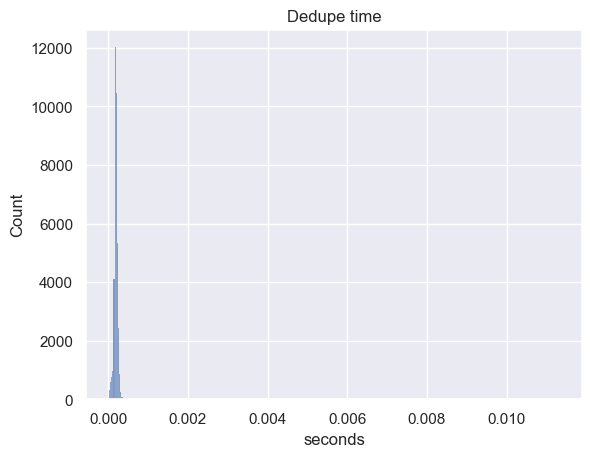

In [16]:
_ = sns.histplot(times_dedupe).set(title="Dedupe time", xlabel="seconds")

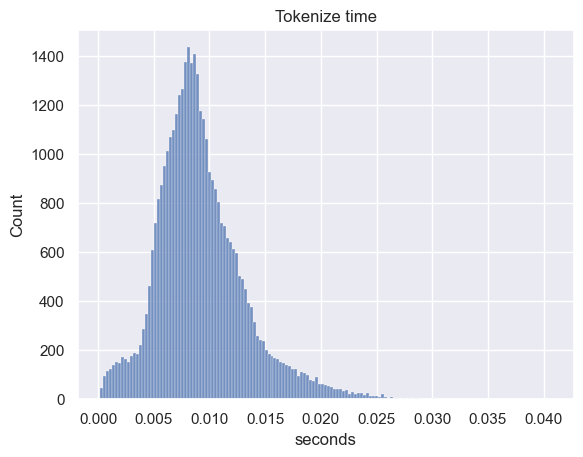

In [17]:
_ = sns.histplot(times_tokenize).set(title="Tokenize time", xlabel="seconds")


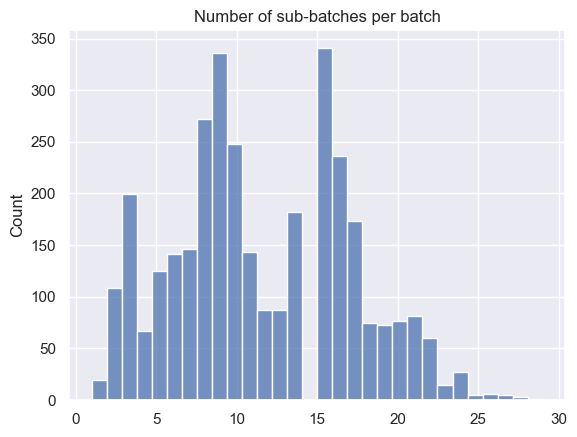

In [18]:
_ = sns.histplot(num_sub_batches_per_batch).set(title="Number of sub-batches per batch")